# 05 — Weather Fundamentals

**Evaluation: Insight** — How does weather affect production and consumption?

Temperature drives demand (heating/cooling). Wind and cloud cover drive wind/solar generation. We quantify these relationships.

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_weather, load_total_load, load_generation_pivot, load_spot_price

# Expand hourly weather to 15-min (ffill). Load/gen stay at 15-min.
def weather_15min(weather_df):
    full_idx = pd.date_range(weather_df.index.min(), weather_df.index.max(), freq="15min", tz="UTC")
    return weather_df.reindex(full_idx).ffill()

weather = load_weather("DE")
weather_15 = weather_15min(weather)

## Temperature vs consumption (Germany)

Correlation: temperature vs load = -0.200
Cold → more heating → higher load. Hot → more cooling → higher load. Sweet spot ~15-20°C.


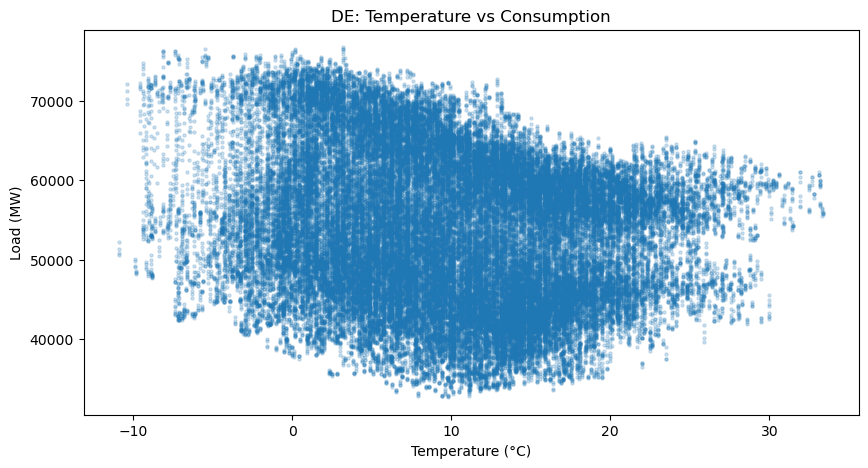

In [4]:
load = load_total_load("DE")  # already 15-min

join = weather_15[["temperature"]].join(load, how="inner").dropna()

corr = join["temperature"].corr(join["load"], method="spearman")
print(f"Correlation: temperature vs load = {corr:.3f}")
print("Cold → more heating → higher load. Hot → more cooling → higher load. Sweet spot ~15-20°C.")

plt.figure(figsize=(10, 5))
plt.scatter(join["temperature"], join["load"], alpha=0.2, s=5)
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (MW)")
plt.title("DE: Temperature vs Consumption")
plt.show()

## Wind speed vs wind generation

Correlation: wind_speed vs wind_generation = 0.676


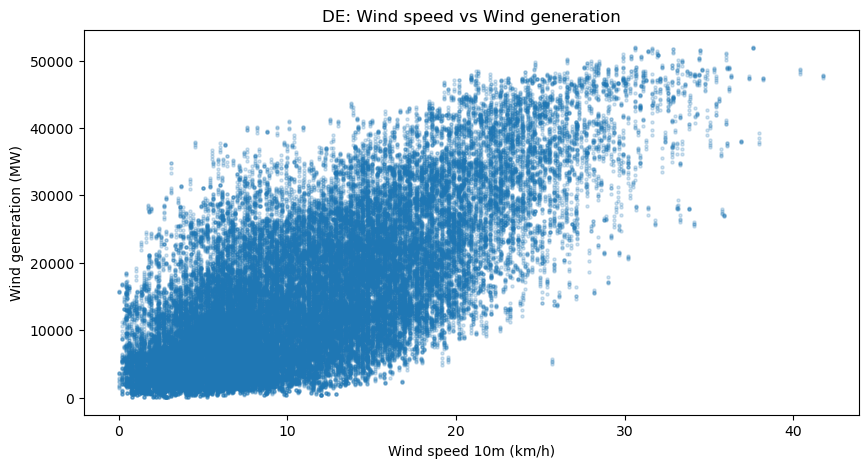

In [5]:
gen = load_generation_pivot("DE")  # already 15-min
wind_cols = [c for c in gen.columns if "WIND" in c]
gen["wind_total"] = gen[wind_cols].sum(axis=1)

join_w = weather_15[["wind_speed_10m"]].join(gen[["wind_total"]], how="inner").dropna()

corr_w = join_w["wind_speed_10m"].corr(join_w["wind_total"], method="spearman")
print(f"Correlation: wind_speed vs wind_generation = {corr_w:.3f}")

plt.figure(figsize=(10, 5))
plt.scatter(join_w["wind_speed_10m"], join_w["wind_total"], alpha=0.2, s=5)
plt.xlabel("Wind speed 10m (km/h)")
plt.ylabel("Wind generation (MW)")
plt.title("DE: Wind speed vs Wind generation")
plt.show()

## Cloud cover vs solar generation

Correlation (daylight): cloud_cover vs solar = -0.122


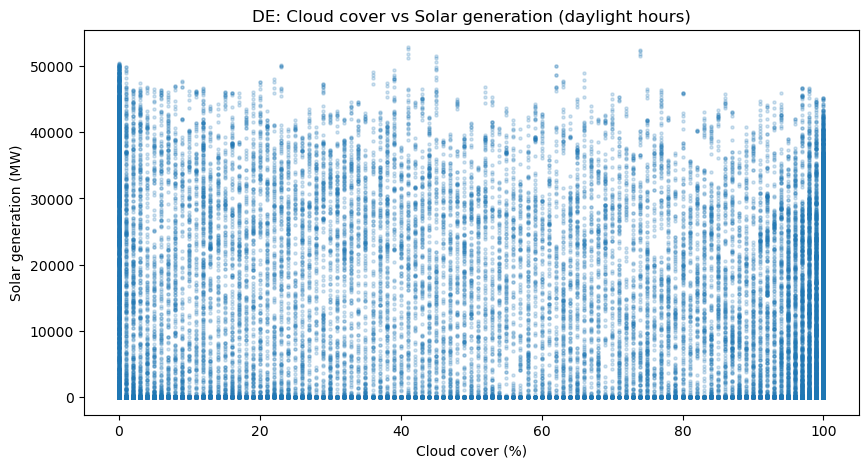

In [7]:
if "SOLAR" in gen.columns:
    join_s = weather_15[["cloud_cover"]].join(gen[["SOLAR"]], how="inner").dropna()
    join_s["hour"] = join_s.index.hour
    # Only daylight hours
    day = join_s[(join_s["hour"] >= 6) & (join_s["hour"] <= 23)]
    corr_s = day["cloud_cover"].corr(day["SOLAR"], method="spearman")
    print(f"Correlation (daylight): cloud_cover vs solar = {corr_s:.3f}")
    plt.figure(figsize=(10, 5))
    plt.scatter(day["cloud_cover"], day["SOLAR"], alpha=0.2, s=5)
    plt.xlabel("Cloud cover (%)")
    plt.ylabel("Solar generation (MW)")
    plt.title("DE: Cloud cover vs Solar generation (daylight hours)")
    plt.show()

## Weather → spot price (composite)

In [8]:
sp = load_spot_price("DE")
# Spot price is hourly; expand to 15-min with ffill
full_idx = pd.date_range(sp.index.min(), sp.index.max(), freq="15min", tz="UTC")
sp_15 = sp.reindex(full_idx).ffill()
join_all = weather_15.join(sp_15, how="inner").dropna()

for col in ["temperature", "wind_speed_10m", "cloud_cover"]:
    if col in join_all.columns:
        c = join_all[col].corr(join_all["price"])
        print(f"{col} vs price: {c:.3f}")

print("\nInterpretation: High wind/solar (low cloud) → lower marginal cost → lower price.")

temperature vs price: -0.268
wind_speed_10m vs price: -0.364
cloud_cover vs price: 0.010

Interpretation: High wind/solar (low cloud) → lower marginal cost → lower price.
